In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "A1"

## Comparing decoding across ROI sizes

22 subjects in 50 voxels mask. Visual modality: t(21)=5.5060, p=0.0000. Auditory modality: t(21)=4.8539, p=0.0000
20 subjects in 100 voxels mask. Visual modality: t(19)=5.7802, p=0.0000. Auditory modality: t(19)=4.5002, p=0.0001
18 subjects in 150 voxels mask. Visual modality: t(17)=7.4451, p=0.0000. Auditory modality: t(17)=5.3114, p=0.0000
17 subjects in 200 voxels mask. Visual modality: t(16)=6.7675, p=0.0000. Auditory modality: t(16)=6.7826, p=0.0000
16 subjects in 250 voxels mask. Visual modality: t(15)=8.6400, p=0.0000. Auditory modality: t(15)=5.3625, p=0.0000
13 subjects in 300 voxels mask. Visual modality: t(12)=8.2268, p=0.0000. Auditory modality: t(12)=7.1240, p=0.0000
24 subjects in funcloc voxels mask. Visual modality: t(23)=7.7719, p=0.0000. Auditory modality: t(23)=7.7770, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=9.2754, p=0.0000. Auditory modality: t(24)=10.2829, p=0.0000


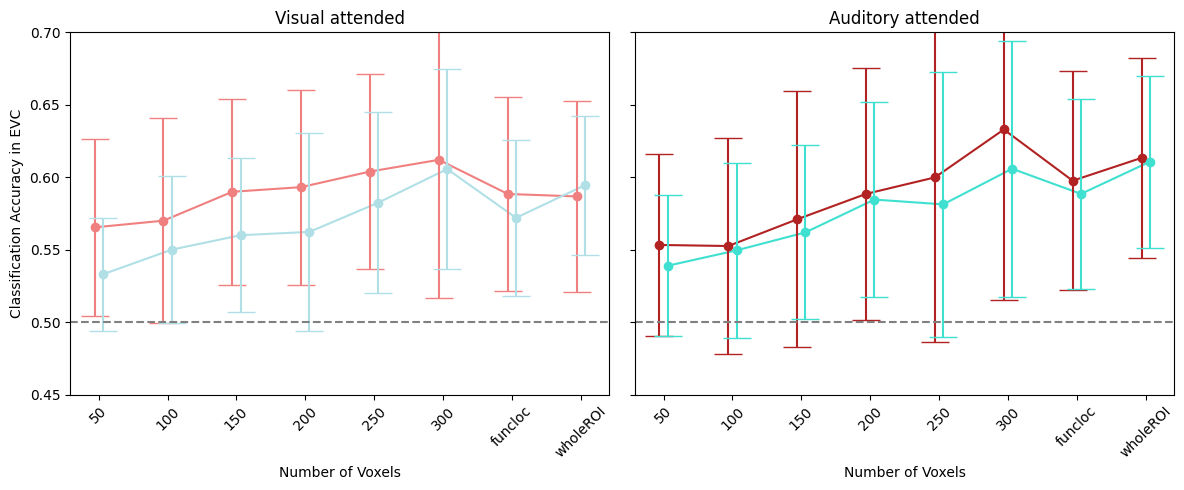

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "a_pred", save_fig=False)

## Analyze specific ROIs

In [3]:
ROI = "A1"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

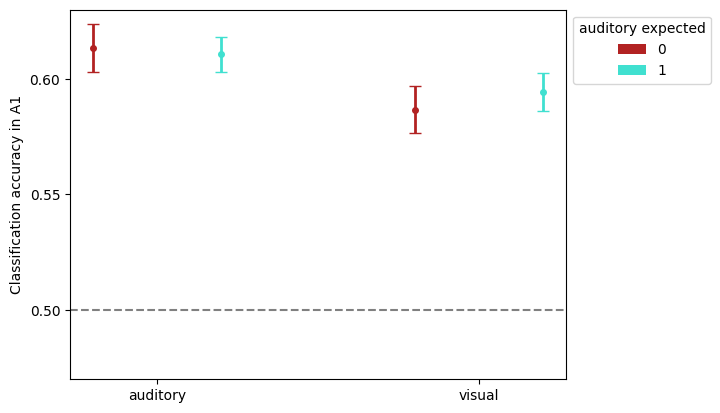

In [4]:
y = "correct"
x = "modality"
hue = "a_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "auditory expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.ylim(0.47, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [14]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.011476,1,24,0.011476,5.131736,0.032798,0.032798,0.021446,1.0
1,a_pred,0.000162,1,24,0.000162,0.105277,0.748398,0.748398,0.000308,1.0
2,modality * a_pred,0.000674,1,24,0.000674,0.264092,0.612022,0.612022,0.001285,1.0


In [15]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,2.265333,24.0,two-sided,0.032798,NaN,NaN,1.794,0.316739
1,a_pred,-,0,1,True,True,-0.324464,24.0,two-sided,0.748398,NaN,NaN,0.221,-0.038342
2,modality * a_pred,auditory,0,1,True,True,0.212951,24.0,two-sided,0.833164,0.833164,fdr_bh,0.215,0.033520
3,modality * a_pred,visual,0,1,True,True,-0.589680,24.0,two-sided,0.560916,0.833164,fdr_bh,0.247,-0.109262


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

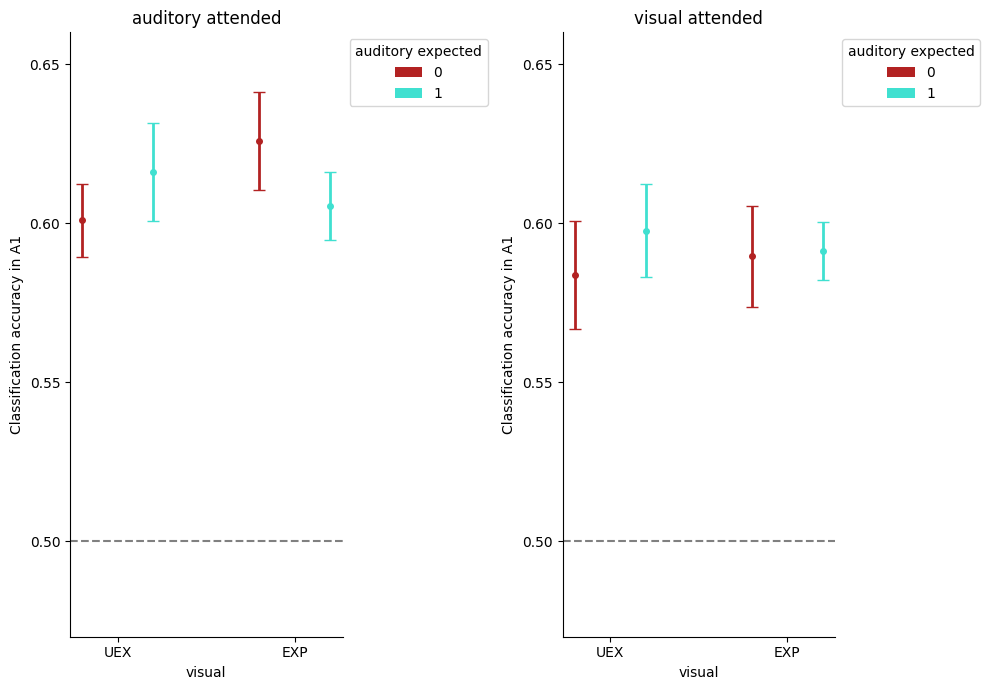

In [5]:
y = "correct"
x = "v_pred"
hue = "a_pred"
id = "subj"
ROI = "A1"
save_fig = True
ylim = (0.47, 0.66)
yticks = [0.5, 0.55, 0.6, 0.65]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "auditory expected", id, ROI, save_fig, ylim, yticks
)

In [21]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,v_pred,0.001254,1,24,0.001254,0.232044,0.634376,0.634376,0.001543,1.0
1,auditory attended,1,a_pred,0.000176,1,24,0.000176,0.045348,0.833164,0.833164,0.000216,1.0
2,auditory attended,2,v_pred * a_pred,0.008010,1,24,0.008010,1.912744,0.179392,0.179392,0.009774,1.0
3,visual attended,0,v_pred,0.000002,1,24,0.000002,0.000335,0.985538,0.985538,0.000003,1.0
4,visual attended,1,a_pred,0.001495,1,24,0.001495,0.347723,0.560916,0.560916,0.002018,1.0
5,visual attended,2,v_pred * a_pred,0.000925,1,24,0.000925,0.197647,0.660610,0.660610,0.001250,1.0


In [22]:
posthoc_df

,level_0,level_1,Contrast,v_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,auditory attended,0,v_pred,-,0,1,True,True,-0.481710,24.0,two-sided,0.634376,NaN,NaN,0.234,-0.086888
1,auditory attended,1,a_pred,-,0,1,True,True,0.212951,24.0,two-sided,0.833164,NaN,NaN,0.215,0.033520
2,auditory attended,2,v_pred * a_pred,0,0,1,True,True,-0.835035,24.0,two-sided,0.411934,0.411934,fdr_bh,0.289,-0.142638
3,auditory attended,3,v_pred * a_pred,1,0,1,True,True,1.164879,24.0,two-sided,0.255516,0.411934,fdr_bh,0.387,0.264849
4,visual attended,0,v_pred,-,0,1,True,True,0.018316,24.0,two-sided,0.985538,NaN,NaN,0.211,0.003998
5,visual attended,1,a_pred,-,0,1,True,True,-0.589680,24.0,two-sided,0.560916,NaN,NaN,0.247,-0.109262
6,visual attended,2,v_pred * a_pred,0,0,1,True,True,-0.627708,24.0,two-sided,0.536123,0.914992,fdr_bh,0.252,-0.130615
7,visual attended,3,v_pred * a_pred,1,0,1,True,True,-0.107874,24.0,two-sided,0.914992,0.914992,fdr_bh,0.212,-0.024051
